Encoding SBERT embeddings for test set...


c:\Users\yagni\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Batches: 100%|██████████| 20/20 [01:36<00:00,  4.82s/it]



=== Evaluation Results ===
          Model  accuracy  precision    recall        f1
0  SVC (TF-IDF)  0.751503   0.752147  0.751503  0.748642
1    LR (SBERT)  0.735471   0.746071  0.735471  0.738814


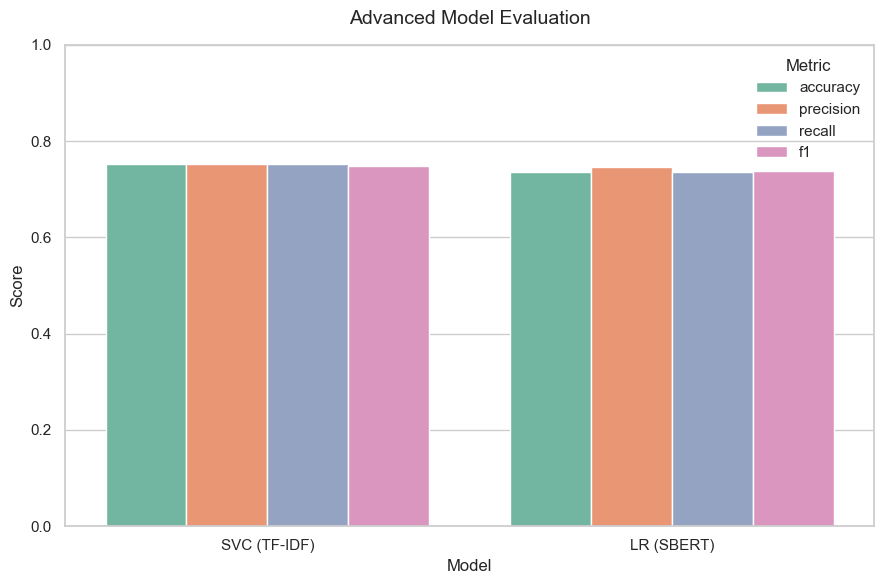

In [9]:
import os
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer

# === Paths ===
DATA_PATH = "../data/processed/test_set.csv"
MODEL_DIR = "../backend/src/models"

# === Load test data ===
df = pd.read_csv(DATA_PATH).dropna(subset=["combined_text", "category"]).copy()
X_test = df["combined_text"]
y_test = df["category"]

# Encode labels numerically (same mapping as in training)
labels = sorted(df["category"].unique())
label2id = {l:i for i,l in enumerate(labels)}
y_test = y_test.map(label2id)

# === Load TF-IDF vectorizers ===
tfidf_word = joblib.load(os.path.join(MODEL_DIR, "tfidf_word.pkl"))
tfidf_char = joblib.load(os.path.join(MODEL_DIR, "tfidf_char.pkl"))

X_test_word = tfidf_word.transform(X_test)
X_test_char = tfidf_char.transform(X_test)
from scipy.sparse import hstack
X_test_tfidf = hstack([X_test_word, X_test_char])

# === Load models ===
svc_model = joblib.load(os.path.join(MODEL_DIR, "svc_model.pkl"))
lr_sbert_model = joblib.load(os.path.join(MODEL_DIR, "lr_sbert.pkl"))

# === Evaluate SVC (TF-IDF) ===
y_pred_svc = svc_model.predict(X_test_tfidf)
svc_results = {
    "accuracy": accuracy_score(y_test, y_pred_svc),
    "precision": precision_score(y_test, y_pred_svc, average='weighted'),
    "recall": recall_score(y_test, y_pred_svc, average='weighted'),
    "f1": f1_score(y_test, y_pred_svc, average='weighted')
}

# === Evaluate LR (SBERT) ===
print("Encoding SBERT embeddings for test set...")
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
X_test_sbert = sbert_model.encode(X_test, show_progress_bar=True, batch_size=128)
y_pred_lr = lr_sbert_model.predict(X_test_sbert)
lr_results = {
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "precision": precision_score(y_test, y_pred_lr, average='weighted'),
    "recall": recall_score(y_test, y_pred_lr, average='weighted'),
    "f1": f1_score(y_test, y_pred_lr, average='weighted')
}

# === Combine Results ===
results = {
    "SVC (TF-IDF)": svc_results,
    "LR (SBERT)": lr_results
}

df_results = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})
print("\n=== Evaluation Results ===")
print(df_results)

# === Plot ===
sns.set(style="whitegrid", palette="Set2")
df_plot = df_results.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(9,6))
sns.barplot(data=df_plot, x="Model", y="Score", hue="Metric")
plt.title("Advanced Model Evaluation", fontsize=14, pad=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

../backend/src/models\tfidf_vectorizer.pkl
